In [1]:
import os
import glob
import shutil
import itertools
import time

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from tqdm.notebook import tqdm

import cv2

import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    balanced_accuracy_score,
    roc_curve
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import Xception
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications import InceptionV3


print("TensorFlow version:", tf.__version__)

2026-03-26 04:22:43.269577: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774498963.451019      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774498963.504223      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774498963.932471      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774498963.932512      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774498963.932515      24 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0


# Load Data

In [2]:
import os

# Dataset path
dataset_path = "/kaggle/input/datasets/mdmoonrahmannayem/diabates-retinopathy/Augmented Dataset"

# Dictionary to store class counts
class_counts = {}

# Count images in each class
for class_name in os.listdir(dataset_path):

    class_path = os.path.join(dataset_path, class_name)

    if os.path.isdir(class_path):

        images = [
            f for f in os.listdir(class_path)
            if f.lower().endswith((".png", ".jpg", ".jpeg"))
        ]

        class_counts[class_name] = len(images)

# Print total classes
print("Total Classes:", len(class_counts))
print()

# Print image count per class
print("Image Count Per Class:")
for class_name, count in class_counts.items():
    print(f"{class_name} : {count} images")

# Calculate total images
total_images = sum(class_counts.values())

print("\nClass Percentage Distribution:")

# Print percentage of each class
for class_name, count in class_counts.items():
    percentage = (count / total_images) * 100
    print(f"{class_name} : {percentage:.2f}%")

Total Classes: 2

Image Count Per Class:
Healthy : 2676 images
Diabetic Retinopathy : 3444 images

Class Percentage Distribution:
Healthy : 43.73%
Diabetic Retinopathy : 56.27%


# Sample Image Visualization

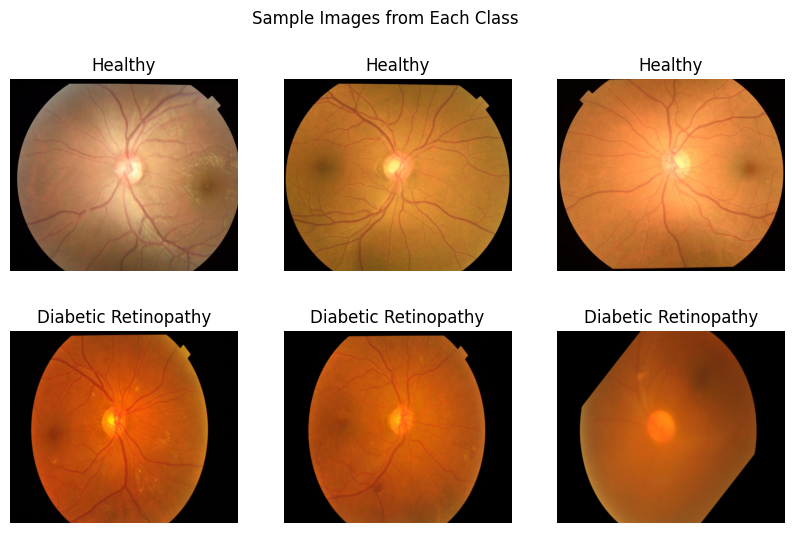

In [3]:
import random
classes = os.listdir(dataset_path)

plt.figure(figsize=(10,6))

plot_index = 1

for class_name in classes:

    class_path = os.path.join(dataset_path, class_name)

    images = [img for img in os.listdir(class_path) if img.endswith((".png",".jpg",".jpeg"))]

    samples = random.sample(images, min(3,len(images)))

    for img_name in samples:

        img_path = os.path.join(class_path,img_name)

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(2,3,plot_index)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis("off")

        plot_index += 1

plt.suptitle("Sample Images from Each Class")

plt.show()

# Dataset Split

In [4]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

dataset_path = "/kaggle/input/datasets/mdmoonrahmannayem/diabates-retinopathy/Augmented Dataset"

image_paths = []
labels = []

for label in os.listdir(dataset_path):

    class_path = os.path.join(dataset_path, label)

    for img in os.listdir(class_path):

        image_paths.append(os.path.join(class_path, img))
        labels.append(label)

df = pd.DataFrame({
    "filename": image_paths,
    "class": labels
})

# Step 1: Train 70% / Test 30%
train_df, test_df = train_test_split(
    df,
    test_size=0.3,
    stratify=df["class"],
    random_state=42
)

# Step 2: Validation = 10% of Train
train_df, val_df = train_test_split(
    train_df,
    test_size=0.1,
    stratify=train_df["class"],
    random_state=42
)

# Print results
print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

print("\nTrain class distribution:")
print(train_df["class"].value_counts())

print("\nValidation class distribution:")
print(val_df["class"].value_counts())

print("\nTest class distribution:")
print(test_df["class"].value_counts())

# Save CSV
train_df.to_csv("/kaggle/working/train_split.csv", index=False)
val_df.to_csv("/kaggle/working/val_split.csv", index=False)
test_df.to_csv("/kaggle/working/test_split.csv", index=False)

print("\nTrain / Validation / Test CSV files saved successfully!")

Train size: 3855
Validation size: 429
Test size: 1836

Train class distribution:
class
Diabetic Retinopathy    2170
Healthy                 1685
Name: count, dtype: int64

Validation class distribution:
class
Diabetic Retinopathy    241
Healthy                 188
Name: count, dtype: int64

Test class distribution:
class
Diabetic Retinopathy    1033
Healthy                  803
Name: count, dtype: int64

Train / Validation / Test CSV files saved successfully!


# Data Generators

In [5]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col="filename",
    y_col="class",
    target_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

val_generator = test_datagen.flow_from_dataframe(
    val_df,
    x_col="filename",
    y_col="class",
    target_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

test_generator = test_datagen.flow_from_dataframe(
    test_df,
    x_col="filename",
    y_col="class",
    target_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

# Class imbalance weight
class_weight = {0:1.14, 1:0.89}

Found 3855 validated image filenames belonging to 2 classes.
Found 429 validated image filenames belonging to 2 classes.
Found 1836 validated image filenames belonging to 2 classes.


# Model Training (InceptionV3)

In [6]:
# Load pretrained InceptionV3
base_model = InceptionV3(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze all layers first
for layer in base_model.layers:
    layer.trainable = False

# Unfreeze last 30 layers (fine-tuning)
for layer in base_model.layers[-30:]:
    layer.trainable = True

# Custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
output = Dense(1, activation="sigmoid")(x)

# Final model
model = Model(inputs=base_model.input, outputs=output)

# Compile
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Early stopping
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

# Training time start
start_train = time.time()

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=100,
    class_weight=class_weight,
    callbacks=[early_stop]
)

training_time = time.time() - start_train

print("Training Time:", training_time)


I0000 00:00:1774498996.939898      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100


I0000 00:00:1774499011.834172      72 service.cc:152] XLA service 0x7e6b900066c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774499011.834220      72 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1774499014.589193      72 cuda_dnn.cc:529] Loaded cuDNN version 91002


  2/121 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - accuracy: 0.4609 - loss: 0.7362  

I0000 00:00:1774499022.930542      72 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


121/121 ━━━━━━━━━━━━━━━━━━━━ 137s 972ms/step - accuracy: 0.8981 - loss: 0.2264 - val_accuracy: 0.9580 - val_loss: 0.1301
Epoch 2/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 82s 678ms/step - accuracy: 0.9688 - loss: 0.0869 - val_accuracy: 0.9720 - val_loss: 0.0878
Epoch 3/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 83s 682ms/step - accuracy: 0.9732 - loss: 0.0719 - val_accuracy: 0.9767 - val_loss: 0.0683
Epoch 4/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 84s 691ms/step - accuracy: 0.9720 - loss: 0.0711 - val_accuracy: 0.9744 - val_loss: 0.0729
Epoch 5/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 82s 676ms/step - accuracy: 0.9850 - loss: 0.0435 - val_accuracy: 0.9697 - val_loss: 0.0706
Epoch 6/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 84s 697ms/step - accuracy: 0.9765 - loss: 0.0615 - val_accuracy: 0.9883 - val_loss: 0.0527
Epoch 7/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 84s 693ms/step - accuracy: 0.9896 - loss: 0.0310 - val_accuracy: 0.9790 - val_loss: 0.0903
Epoch 8/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 84s 698ms/step - accuracy: 0.9850 - loss: 0.04

# Evaluation Metrics

In [7]:
y_prob = model.predict(test_generator)
y_pred = (y_prob>0.5).astype(int)

y_true = test_generator.classes

TN,FP,FN,TP = confusion_matrix(y_true,y_pred).ravel()

accuracy = accuracy_score(y_true,y_pred)
precision = precision_score(y_true,y_pred)
recall = recall_score(y_true,y_pred)
f1 = f1_score(y_true,y_pred)
balanced_acc = balanced_accuracy_score(y_true,y_pred)
auc = roc_auc_score(y_true,y_prob)

specificity = TN/(TN+FP)
fnr = FN/(FN+TP)
fpr = FP/(FP+TN)

print("\n===== Model Evaluation =====\n")

print("Accuracy:",accuracy)
print("Precision:",precision)
print("Recall:",recall)
print("F1 Score:",f1)
print("Balanced Accuracy:",balanced_acc)
print("Specificity:",specificity)
print("FNR:",fnr)
print("FPR:",fpr)
print("AUC-ROC:",auc)

58/58 ━━━━━━━━━━━━━━━━━━━━ 44s 654ms/step

===== Model Evaluation =====

Accuracy: 0.9940087145969498
Precision: 0.9900990099009901
Recall: 0.9962640099626401
F1 Score: 0.9931719428926132
Balanced Accuracy: 0.9942597881371767
Specificity: 0.9922555663117134
FNR: 0.0037359900373599006
FPR: 0.007744433688286544
AUC-ROC: 0.9998927063203211


# Confusion Matrix

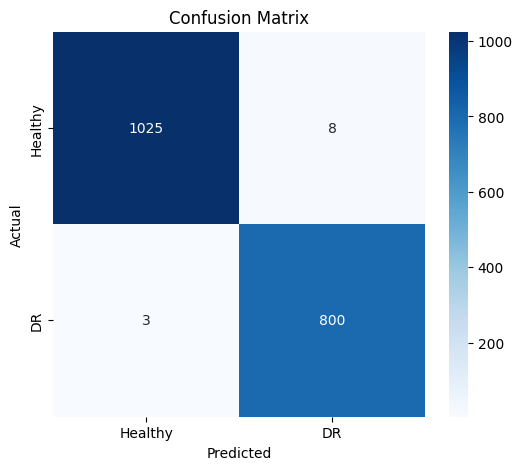

In [8]:
cm = confusion_matrix(y_true,y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Healthy","DR"],
    yticklabels=["Healthy","DR"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# ROC Curve

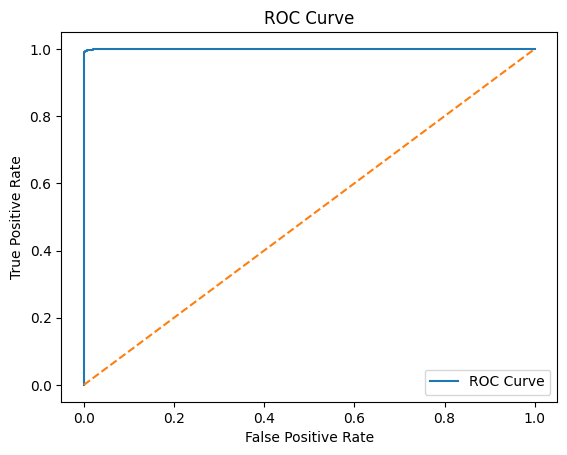

In [9]:
fpr_curve,tpr_curve,_ = roc_curve(y_true,y_prob)

plt.plot(fpr_curve,tpr_curve,label="ROC Curve")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

# Image Prediction Visualization

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


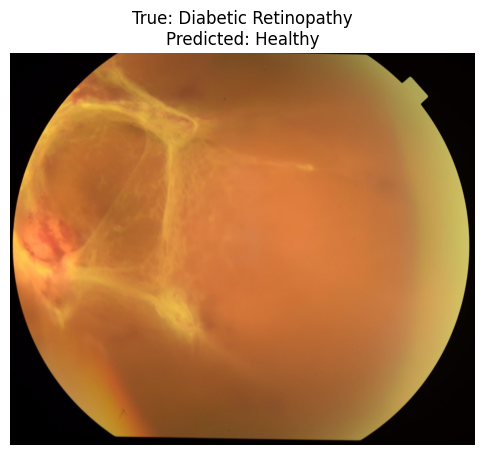

In [10]:
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt

# random test image
sample = test_df.sample(1)

img_path = sample["filename"].values[0]
true_label = sample["class"].values[0]

# read image
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# resize for model
img_resized = cv2.resize(img_rgb,(224,224))
img_input = img_resized/255.0
img_input = np.expand_dims(img_input,axis=0)

# prediction
pred = model.predict(img_input)

pred_label = "Diabetic Retinopathy" if pred>0.5 else "Healthy"

# show image
plt.figure(figsize=(6,6))
plt.imshow(img_rgb)
plt.title(f"True: {true_label}\nPredicted: {pred_label}")
plt.axis("off")
plt.show()

# Data Leakage

In [11]:
# =========================
# Data Leakage Check
# =========================

train_paths = set(train_df["filename"])
val_paths = set(val_df["filename"])
test_paths = set(test_df["filename"])

print("Train vs Test duplicates:", len(train_paths.intersection(test_paths)))
print("Train vs Validation duplicates:", len(train_paths.intersection(val_paths)))
print("Validation vs Test duplicates:", len(val_paths.intersection(test_paths)))

Train vs Test duplicates: 0
Train vs Validation duplicates: 0
Validation vs Test duplicates: 0


# Grad-Cam Visualization

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


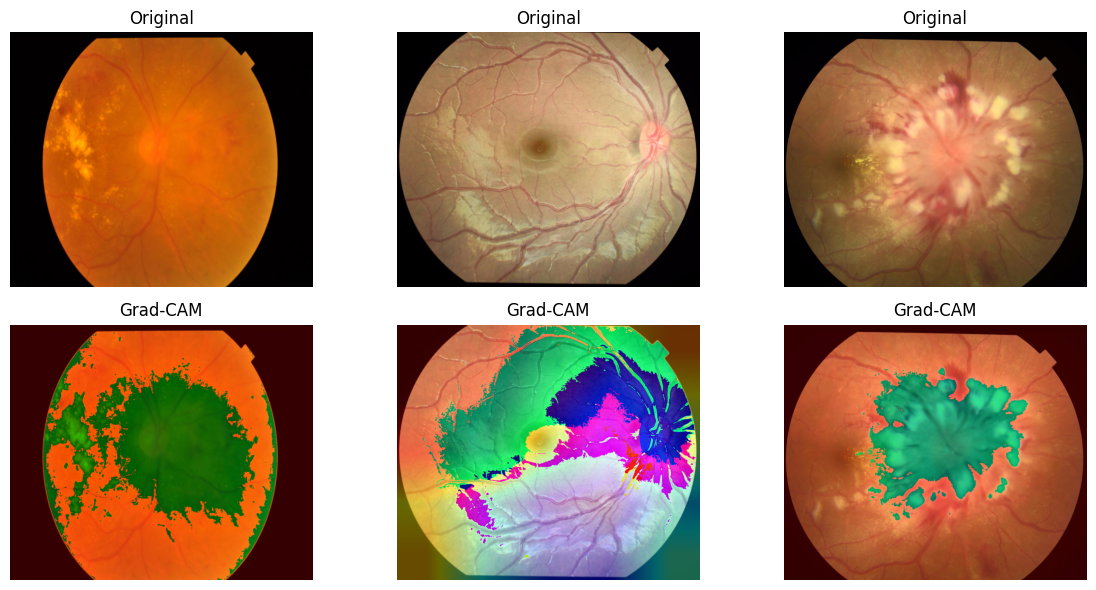

In [12]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

# InceptionV3 last conv layer
last_conv_layer = "mixed10"

plt.figure(figsize=(12,6))

for i in range(3):

    sample = test_df.sample(1)
    img_path = sample["filename"].values[0]

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Inception prefers 299 but 224 works
    img_resized = cv2.resize(img,(224,224))
    img_input = img_resized / 255.0
    img_input = np.expand_dims(img_input,axis=0)

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_input)
        loss = predictions[:,0]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[...,tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = np.maximum(heatmap,0) / np.max(heatmap)

    heatmap = cv2.resize(heatmap,(img.shape[1],img.shape[0]))

    heatmap = np.uint8(255 * heatmap)

    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed_img = heatmap * 0.4 + img

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(2,3,i+4)
    plt.imshow(superimposed_img.astype("uint8"))
    plt.title("Grad-CAM")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Grad-CAM Heatmap (Grid Style Visualization)

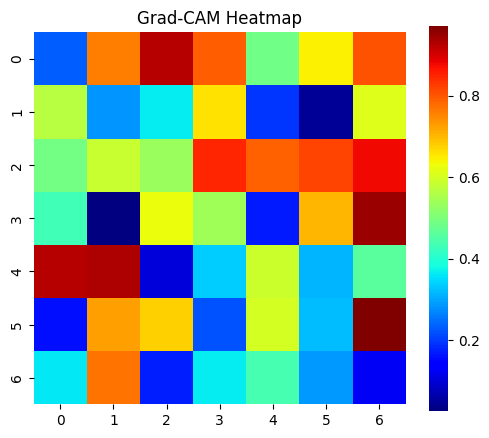

In [13]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Example heatmap values (Grad-CAM output simulate)
heatmap = np.random.rand(7,7)

plt.figure(figsize=(6,5))

sns.heatmap(
    heatmap,
    cmap="jet",
    cbar=True,
    square=True
)

plt.title("Grad-CAM Heatmap")
plt.show()
